# Лабораторная работа №2
## Обработка признаков (часть 2)

**Дисциплина:** Обработка признаков

**Студент:** Пац И.Н.

**Группа:** ИУ5-23М

**Дата:** 03.05.2026

---

## Описание задания

**Цель работы:** Изучение методов масштабирования признаков, обработки выбросов и отбора признаков для повышения качества моделей машинного обучения.

**Задачи:**
1. Масштабирование числовых признаков (не менее 3 методов)
2. Обработка выбросов в числовых признаках (один метод удаления, один метод замены)
3. Обработка нестандартного признака (не числового и не категориального)
4. Отбор признаков: один фильтрующий метод, один метод-обёртка, один встроенный метод

**Используемые наборы данных:**
1. **Auto Imports (UCI)** — характеристики автомобилей (205 записей, 26 признаков).
2. **Auto MPG (UCI)** — расход топлива автомобилей (398 записей, 9 признаков).
3. **California Housing** — цены на жилье в Калифорнии (20640 записей, 10 признаков).

---
## 1. Загрузка библиотек и данных

In [20]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from enum import Enum

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, mutual_info_regression,
    SelectFromModel, RFE
)
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Библиотеки успешно загружены')

Библиотеки успешно загружены


### 1.1. Загрузка датасетов

Загрузим все три датасета из лабораторной работы №1.

In [21]:
# Загрузка данных Auto Imports
auto_cols = [
    'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
    'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
    'wheel-base', 'length', 'width', 'height', 'curb-weight',
    'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system',
    'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
    'city-mpg', 'highway-mpg', 'price'
]
autos = pd.read_csv('../lab1/autos.csv', header=None, names=auto_cols, na_values='?')
print(f'Размер датасета Auto Imports: {autos.shape}')

# Загрузка данных Auto MPG
mpg_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model-year', 'origin', 'car-name']
mpg = pd.read_csv('../lab1/auto_mpg.csv', sep=r'\s+', header=None, names=mpg_cols, na_values='?')
print(f'Размер датасета Auto MPG: {mpg.shape}')

# Загрузка данных California Housing
housing = pd.read_csv('../lab1/house_prices.csv')
print(f'Размер датасета California Housing: {housing.shape}')

print('Все датасеты успешно загружены')

Размер датасета Auto Imports: (205, 26)
Размер датасета Auto MPG: (398, 9)
Размер датасета California Housing: (20640, 10)
Все датасеты успешно загружены


### 1.2. Предварительная обработка данных

Устраним пропуски в данных (аналогично лабораторной работе №1) для дальнейшей работы.

In [22]:
# Устранение пропусков в Auto Imports
autos_clean = autos.copy()

# Заполнение числовых пропусков медианой
num_cols_na = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in num_cols_na:
    autos_clean[col] = autos_clean[col].fillna(autos_clean[col].median())

# Заполнение категориальных пропусков модой
autos_clean['num-of-doors'] = autos_clean['num-of-doors'].fillna(
    autos_clean['num-of-doors'].mode()[0]
)
print(f'Пропусков после обработки Auto Imports: {autos_clean.isnull().sum().sum()}')

# Устранение пропусков в Auto MPG
mpg_clean = mpg.copy()
mpg_clean['horsepower'] = mpg_clean['horsepower'].fillna(mpg_clean['horsepower'].median())
print(f'Пропусков после обработки Auto MPG: {mpg_clean.isnull().sum().sum()}')

# Устранение пропусков в California Housing
housing_clean = housing.copy()
housing_clean['total_bedrooms'] = housing_clean['total_bedrooms'].fillna(
    housing_clean['total_bedrooms'].median()
)
print(f'Пропусков после обработки California Housing: {housing_clean.isnull().sum().sum()}')

Пропусков после обработки Auto Imports: 0
Пропусков после обработки Auto MPG: 0
Пропусков после обработки California Housing: 0


---
## 2. Масштабирование числовых признаков

Масштабирование признаков — важный этап предобработки, особенно для методов, чувствительных к масштабу данных (SVM, линейная регрессия, KNN, PCA и др.).

Рассмотрим следующие методы масштабирования:
1. **StandardScaler** — Z-стандартизация: $z = \frac{x - \mu}{\sigma}$
2. **MinMaxScaler** — приведение к диапазону [0, 1]: $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$
3. **RobustScaler** — устойчивое масштабирование с использованием медианы и IQR: $x_{rob} = \frac{x - median}{IQR}$
4. **MaxAbsScaler** — масштабирование по максимальному абсолютному значению: $x_{scaled} = \frac{x}{|x_{max}|}$

### 2.1. Масштабирование на датасете Auto Imports

Выберем числовые признаки для масштабирования и применим различные методы.

In [23]:
# Выбор числовых признаков для масштабирования
autos_numeric_cols = [
    'wheel-base', 'length', 'width', 'height', 'curb-weight',
    'engine-size', 'bore', 'stroke', 'compression-ratio',
    'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'
]

# Извлечём числовые данные без пропусков
autos_num = autos_clean[autos_numeric_cols].copy()

print('Исходные статистики числовых признаков:')
autos_num.describe().round(2)

Исходные статистики числовых признаков:


,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00
mean,98.76,174.05,65.91,53.72,2555.57,126.91,3.33,3.26,10.14,104.17,5126.10,25.22,30.75,13150.31
std,6.02,12.34,2.15,2.44,520.68,41.64,0.27,0.31,3.97,39.53,477.04,6.54,6.89,7879.12
min,86.60,141.10,60.30,47.80,1488.00,61.00,2.54,2.07,7.00,48.00,4150.00,13.00,16.00,5118.00
25%,94.50,166.30,64.10,52.00,2145.00,97.00,3.15,3.11,8.60,70.00,4800.00,19.00,25.00,7788.00
50%,97.00,173.20,65.50,54.10,2414.00,120.00,3.31,3.29,9.00,95.00,5200.00,24.00,30.00,10295.00
75%,102.40,183.10,66.90,55.50,2935.00,141.00,3.58,3.41,9.40,116.00,5500.00,30.00,34.00,16500.00
max,120.90,208.10,72.30,59.80,4066.00,326.00,3.94,4.17,23.00,288.00,6600.00,49.00,54.00,45400.00


In [24]:
# Применение различных методов масштабирования

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler()
}

scaled_dfs = {}
for name, scaler in scalers.items():
    scaled_data = scaler.fit_transform(autos_num)
    scaled_dfs[name] = pd.DataFrame(scaled_data, columns=autos_numeric_cols)

# Сравнение статистик после масштабирования
print('Сравнение методов масштабирования (среднее и std для price):')
for name in scalers:
    mean_val = scaled_dfs[name]['price'].mean()
    std_val = scaled_dfs[name]['price'].std()
    print(f'{name:20s}: mean = {mean_val:8.4f}, std = {std_val:8.4f}')

Сравнение методов масштабирования (среднее и std для price):
StandardScaler      : mean =  -0.0000, std =   1.0024
MinMaxScaler        : mean =   0.1994, std =   0.1956
RobustScaler        : mean =   0.3277, std =   0.9044
MaxAbsScaler        : mean =   0.2897, std =   0.1735


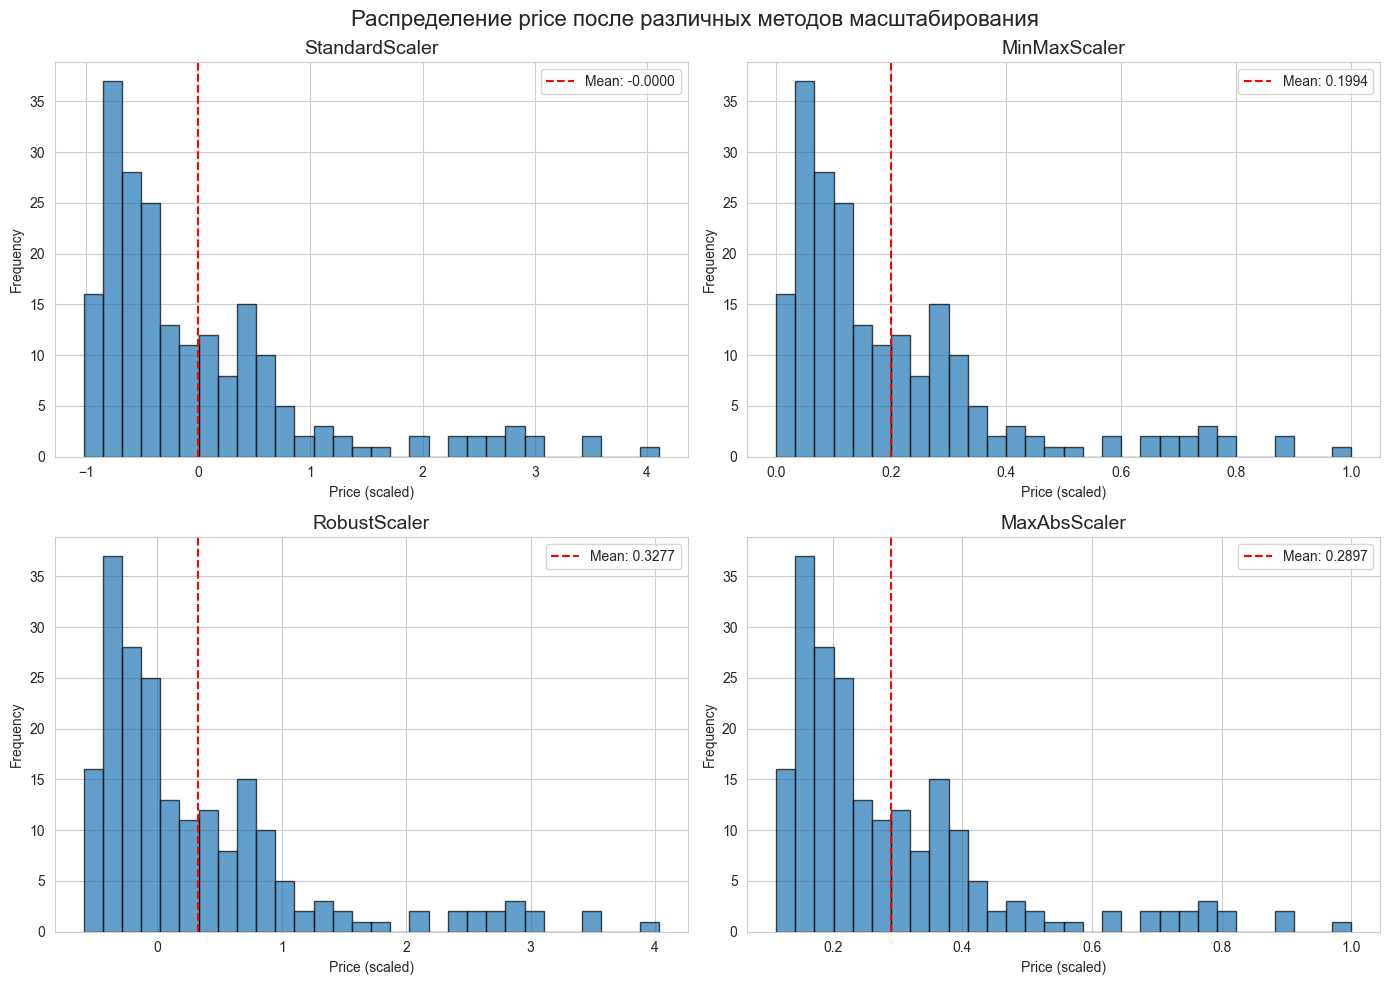

In [25]:
# Визуализация распределения price после различных методов масштабирования
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, df_scaled) in enumerate(scaled_dfs.items()):
    ax = axes[idx]
    ax.hist(df_scaled['price'], bins=30, alpha=0.7, edgecolor='black')
    ax.set_title(f'{name}', fontsize=14)
    ax.set_xlabel('Price (scaled)')
    ax.set_ylabel('Frequency')
    ax.axvline(df_scaled['price'].mean(), color='red', linestyle='--',
               label=f'Mean: {df_scaled["price"].mean():.4f}')
    ax.legend()

plt.suptitle('Распределение price после различных методов масштабирования', fontsize=16)
plt.tight_layout()
plt.show()

### 2.2. Масштабирование на датасете Auto MPG

Продемонстрируем влияние масштабирования на модель линейной регрессии.

In [26]:
# Подготовка данных Auto MPG
mpg_num = mpg_clean[['mpg', 'cylinders', 'displacement', 'horsepower',
                      'weight', 'acceleration', 'model-year']].copy()

X = mpg_num.drop('mpg', axis=1)
y = mpg_num['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер обучающей выборки: (318, 6)
Размер тестовой выборки: (80, 6)


In [27]:
# Сравнение качества линейной регрессии с масштабированием и без

results = []

# Без масштабирования
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
results.append({
    'Method': 'Без масштабирования',
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'R2': r2_score(y_test, y_pred)
})

# С масштабированием
scalers_to_test = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

for name, scaler in scalers_to_test.items():
    pipeline = Pipeline([
        ('scaler', scaler),
        ('lr', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results.append({
        'Method': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print('Сравнение качества линейной регрессии:')
print(results_df.round(4))

Сравнение качества линейной регрессии:
                Method    RMSE      R2
0  Без масштабирования  3.0725  0.8244
1       StandardScaler  3.0725  0.8244
2         MinMaxScaler  3.0725  0.8244
3         RobustScaler  3.0725  0.8244


---
## 3. Обработка выбросов в числовых признаках

Выбросы (outliers) — это наблюдения, которые значительно отличаются от остальных данных. Они могут негативно влиять на обучение моделей.

Рассмотрим три метода обнаружения выбросов:
1. **Правило трёх сигм (3-sigma rule)** — выбросы за пределами $\mu \pm 3\sigma$
2. **Квантильный метод** — выбросы за пределами 5% и 95% перцентилей
3. **Метод межквартильного размаха (IQR)** — выбросы за пределами $Q1 - 1.5 \cdot IQR$ и $Q3 + 1.5 \cdot IQR$

Для каждого метода применим:
- **Удаление** выбросов
- **Замену** выбросов на граничные значения (capping/winsorizing)

### 3.1. Обнаружение выбросов в Auto Imports

Проанализируем признаки `price`, `horsepower`, `compression-ratio` на наличие выбросов.

In [28]:
# Функции для обнаружения выбросов (из лекций)

class OutlierBoundaryType(Enum):
    SIGMA = 1
    QUANTILE = 2
    IRQ = 3

def get_outlier_boundaries(df, col, outlier_boundary_type: OutlierBoundaryType):
    if outlier_boundary_type == OutlierBoundaryType.SIGMA:
        K1 = 3
        lower_boundary = df[col].mean() - (K1 * df[col].std())
        upper_boundary = df[col].mean() + (K1 * df[col].std())
    elif outlier_boundary_type == OutlierBoundaryType.QUANTILE:
        lower_boundary = df[col].quantile(0.05)
        upper_boundary = df[col].quantile(0.95)
    elif outlier_boundary_type == OutlierBoundaryType.IRQ:
        K2 = 1.5
        IQR = df[col].quantile(0.75) - df[col].quantile(0.25)
        lower_boundary = df[col].quantile(0.25) - (K2 * IQR)
        upper_boundary = df[col].quantile(0.75) + (K2 * IQR)
    return lower_boundary, upper_boundary

def detect_outliers(df, col, method: OutlierBoundaryType):
    lower, upper = get_outlier_boundaries(df, col, method)
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

# Анализ выбросов в признаке price
print('Анализ выбросов в признаке price (Auto Imports):')
print('=' * 60)

for method in OutlierBoundaryType:
    outliers, lower, upper = detect_outliers(autos_clean, 'price', method)
    print(f'\n{method.name:10s}: нижняя={lower:10.2f}, верхняя={upper:10.2f}')
    print(f'           количество выбросов: {len(outliers)} ({len(outliers)/len(autos_clean)*100:.2f}%)')

Анализ выбросов в признаке price (Auto Imports):

SIGMA     : нижняя= -10487.06, верхняя=  36787.67
           количество выбросов: 5 (2.44%)

QUANTILE  : нижняя=   6197.00, верхняя=  32472.40
           количество выбросов: 22 (10.73%)

IRQ       : нижняя=  -5280.00, верхняя=  29568.00
           количество выбросов: 14 (6.83%)


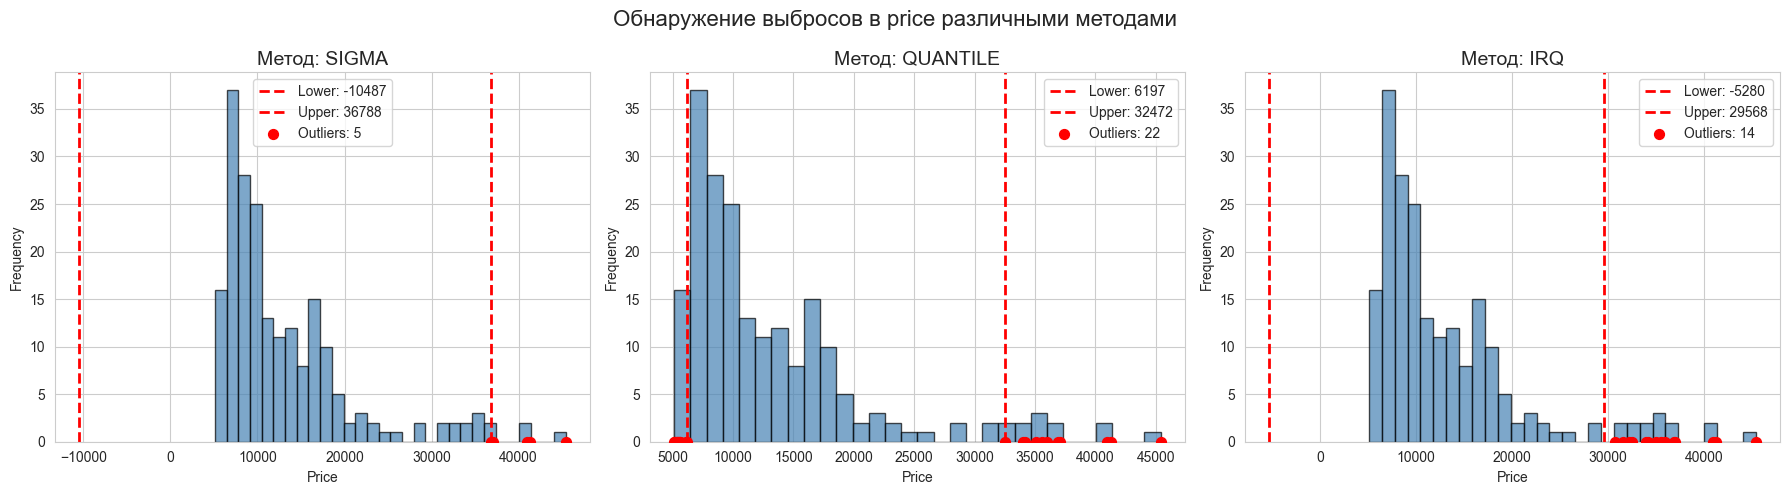

In [29]:
# Визуализация выбросов в price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, method in enumerate(OutlierBoundaryType):
    ax = axes[idx]
    outliers, lower, upper = detect_outliers(autos_clean, 'price', method)
    
    ax.hist(autos_clean['price'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(lower, color='red', linestyle='--', linewidth=2, label=f'Lower: {lower:.0f}')
    ax.axvline(upper, color='red', linestyle='--', linewidth=2, label=f'Upper: {upper:.0f}')
    
    outlier_vals = autos_clean[(autos_clean['price'] < lower) | (autos_clean['price'] > upper)]['price']
    ax.scatter(outlier_vals, [0]*len(outlier_vals), color='red', s=50, zorder=5, label=f'Outliers: {len(outlier_vals)}')
    
    ax.set_title(f'Метод: {method.name}', fontsize=14)
    ax.set_xlabel('Price')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Обнаружение выбросов в price различными методами', fontsize=16)
plt.tight_layout()
plt.show()

### 3.2. Удаление выбросов (метод IQR)

Применим метод IQR для удаления выбросов из датасета Auto Imports.

In [30]:
# Удаление выбросов методом IQR
autos_no_outliers = autos_clean.copy()

cols_to_check = ['price', 'horsepower', 'compression-ratio', 'engine-size']

for col in cols_to_check:
    outliers, lower, upper = detect_outliers(autos_no_outliers, col, OutlierBoundaryType.IRQ)
    autos_no_outliers = autos_no_outliers[
        (autos_no_outliers[col] >= lower) & (autos_no_outliers[col] <= upper)
    ]
    print(f'{col:25s}: удалено {len(outliers)} выбросов')

print(f'\nРазмер исходного датасета: {len(autos_clean)}')
print(f'Размер после удаления выбросов: {len(autos_no_outliers)}')
print(f'Всего удалено: {len(autos_clean) - len(autos_no_outliers)} записей')

price                    : удалено 14 выбросов
horsepower               : удалено 2 выбросов
compression-ratio        : удалено 35 выбросов
engine-size              : удалено 5 выбросов

Размер исходного датасета: 205
Размер после удаления выбросов: 149
Всего удалено: 56 записей


### 3.3. Замена выбросов (Capping методом квантилей)

Вместо удаления выбросов, можно заменить их на граничные значения (winsorizing/capping).

In [31]:
# Замена выбросов на граничные значения (Capping) методом квантилей
autos_capped = autos_clean.copy()

for col in cols_to_check:
    _, lower, upper = detect_outliers(autos_capped, col, OutlierBoundaryType.QUANTILE)
    n_before = ((autos_capped[col] < lower) | (autos_capped[col] > upper)).sum()
    autos_capped[col] = autos_capped[col].clip(lower, upper)
    n_after = ((autos_capped[col] < lower) | (autos_capped[col] > upper)).sum()
    print(f'{col:25s}: заменено {n_before} выбросов')

print(f'\nРазмер датасета не изменился: {len(autos_capped)}')

price                    : заменено 22 выбросов
horsepower               : заменено 19 выбросов
compression-ratio        : заменено 18 выбросов
engine-size              : заменено 17 выбросов

Размер датасета не изменился: 205


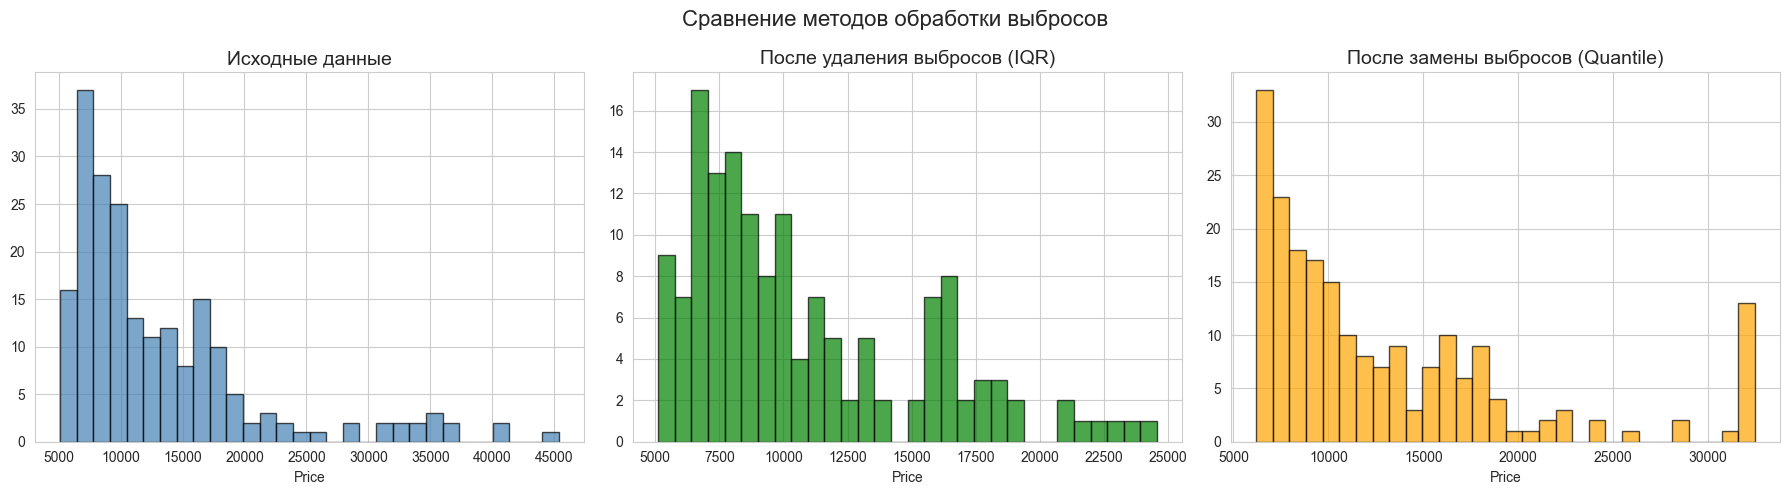

In [32]:
# Сравнение распределения price до и после обработки выбросов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(autos_clean['price'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Исходные данные', fontsize=14)
axes[0].set_xlabel('Price')

axes[1].hist(autos_no_outliers['price'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('После удаления выбросов (IQR)', fontsize=14)
axes[1].set_xlabel('Price')

axes[2].hist(autos_capped['price'], bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[2].set_title('После замены выбросов (Quantile)', fontsize=14)
axes[2].set_xlabel('Price')

plt.suptitle('Сравнение методов обработки выбросов', fontsize=16)
plt.tight_layout()
plt.show()

### 3.4. Влияние обработки выбросов на качество модели

Сравним качество модели линейной регрессии на данных с различной обработкой выбросов.

In [33]:
# Подготовка данных для сравнения
target_col = 'price'
feature_cols = ['wheel-base', 'length', 'width', 'height', 'curb-weight',
                'engine-size', 'bore', 'stroke', 'compression-ratio',
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']

datasets = {
    'Исходные': autos_clean,
    'Удаление (IQR)': autos_no_outliers,
    'Замена (Quantile)': autos_capped
}

results = []
for name, df in datasets.items():
    X = df[feature_cols]
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        'Dataset': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'Size': len(df)
    })

results_df = pd.DataFrame(results)
print('Влияние обработки выбросов на качество модели:')
print(results_df.round(4))

Влияние обработки выбросов на качество модели:
             Dataset       RMSE      R2  Size
0           Исходные  4230.0107  0.7719   205
1     Удаление (IQR)  2330.0560  0.6564   149
2  Замена (Quantile)  3250.3929  0.8180   205


---
## 4. Обработка нестандартного признака

В качестве нестандартного признака (не числового и не категориального) рассмотрим **текстовый признак `car-name`** из датасета Auto MPG.

Текстовые признаки требуют особой обработки — их необходимо преобразовать в числовой формат, извлекая полезную информацию.

Применим следующие подходы:
1. **Извлечение марки автомобиля** — первое слово в названии (make/brand)
2. **CountVectorizer (Bag of Words)** — преобразование текста в матрицу частот слов
3. **Длина названия** — количество символов как числовой признак

In [34]:
# Анализ текстового признака car-name
print('Примеры названий автомобилей:')
print(mpg_clean['car-name'].head(20).to_string())
print(f'\nВсего уникальных названий: {mpg_clean["car-name"].nunique()}')

Примеры названий автомобилей:
0        chevrolet chevelle malibu
1                buick skylark 320
2               plymouth satellite
3                    amc rebel sst
4                      ford torino
5                 ford galaxie 500
6                 chevrolet impala
7                plymouth fury iii
8                 pontiac catalina
9               amc ambassador dpl
10             dodge challenger se
11              plymouth 'cuda 340
12           chevrolet monte carlo
13         buick estate wagon (sw)
14           toyota corona mark ii
15                 plymouth duster
16                      amc hornet
17                   ford maverick
18                    datsun pl510
19    volkswagen 1131 deluxe sedan

Всего уникальных названий: 305


In [35]:
# Метод 1: Извлечение марки автомобиля (первое слово)
mpg_clean['make'] = mpg_clean['car-name'].str.split().str[0]

print('Топ-10 марок автомобилей:')
print(mpg_clean['make'].value_counts().head(10))
print(f'\nВсего уникальных марок: {mpg_clean["make"].nunique()}')

Топ-10 марок автомобилей:
make
ford          51
chevrolet     43
plymouth      31
amc           28
dodge         28
toyota        25
datsun        23
buick         17
pontiac       16
volkswagen    15
Name: count, dtype: int64

Всего уникальных марок: 37


Статистика длины названий:
count    398.000000
mean      16.095477
std        5.571693
min        6.000000
25%       11.000000
50%       16.000000
75%       19.000000
max       36.000000
Name: name_length, dtype: float64


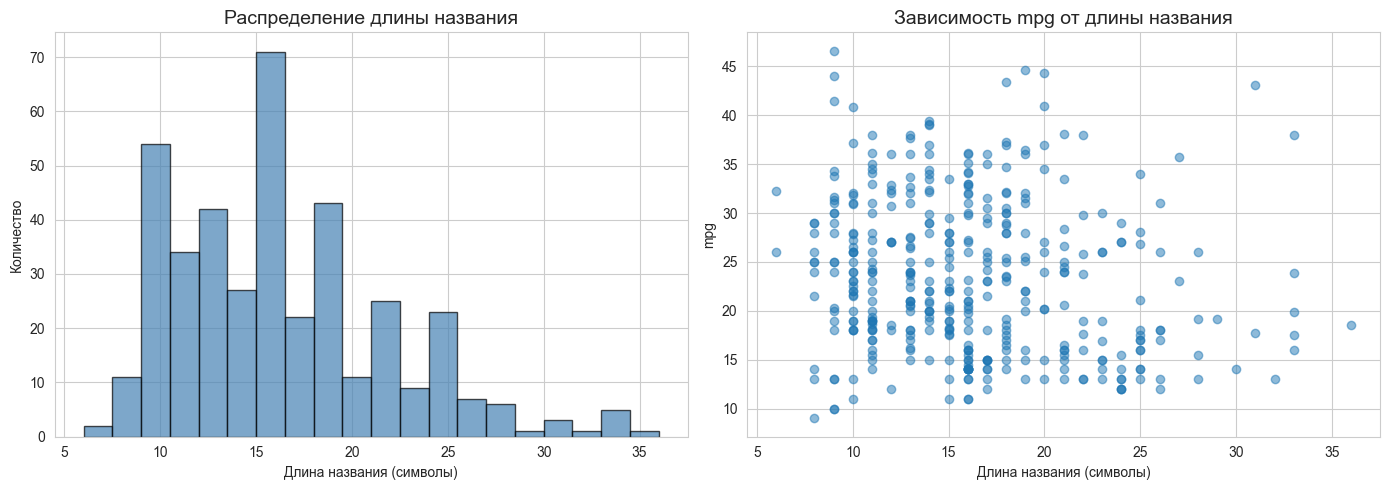

In [36]:
# Метод 2: Длина названия как числовой признак
mpg_clean['name_length'] = mpg_clean['car-name'].str.len()

print('Статистика длины названий:')
print(mpg_clean['name_length'].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mpg_clean['name_length'], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение длины названия', fontsize=14)
axes[0].set_xlabel('Длина названия (символы)')
axes[0].set_ylabel('Количество')

# Зависимость mpg от длины названия
axes[1].scatter(mpg_clean['name_length'], mpg_clean['mpg'], alpha=0.5)
axes[1].set_title('Зависимость mpg от длины названия', fontsize=14)
axes[1].set_xlabel('Длина названия (символы)')
axes[1].set_ylabel('mpg')

plt.tight_layout()
plt.show()

In [38]:
# # Метод 3: One-hot encoding марки автомобиля
# # Возьмём топ-10 марок, остальные объединим в 'Other'
# top_makes = mpg_clean['make'].value_counts().head(10).index
# mpg_clean['make_grouped'] = mpg_clean['make'].apply(
#     lambda x: x if x in top_makes else 'Other'
# )

# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# make_encoded = encoder.fit_transform(mpg_clean[['make_grouped']])
# make_df = pd.DataFrame(
#     make_encoded,
#     columns=encoder.get_feature_names_out(['make'])
# )

# print(f'Размерность one-hot матрицы: {make_df.shape}')
# print('Первые 5 строк:')
# print(make_df.head())

In [40]:
# Метод 4: CountVectorizer (Bag of Words) для названий
vectorizer = CountVectorizer(max_features=20, stop_words=None)
bow_matrix = vectorizer.fit_transform(mpg_clean['car-name'])
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(f'Размерность BoW матрицы: {bow_df.shape}')
print('Топ-20 слов в названиях:')
print(bow_df.sum().sort_values(ascending=False))

Размерность BoW матрицы: (398, 20)
Топ-20 слов в названиях:
ford          51
chevrolet     43
plymouth      31
amc           28
sw            28
dodge         28
toyota        25
datsun        23
custom        18
buick         17
pontiac       16
volkswagen    15
honda         13
mercury       11
brougham      10
corolla       10
oldsmobile    10
mazda         10
rabbit        10
fiat           8
dtype: int64


---
## 5. Отбор признаков (Feature Selection)

Отбор признаков позволяет уменьшить размерность данных, улучшить качество модели и снизить риск переобучения.

Рассмотрим три группы методов:
1. **Фильтрующие методы (Filter)** — оценивают признаки независимо от модели (VarianceThreshold, mutual_info_regression)
2. **Методы-обёртки (Wrapper)** — оценивают подмножества признаков на основе качества модели (SequentialFeatureSelector)
3. **Встроенные методы (Embedded)** — отбор признаков в процессе обучения модели (Lasso, SelectFromModel)

### 5.1. Фильтрующий метод: Mutual Information Regression

Mutual Information оценивает взаимную информацию между признаком и целевой переменной. Чем выше значение, тем более информативен признак.

Применим на датасете California Housing для прогнозирования `median_house_value`.

In [41]:
# Подготовка данных California Housing
# Целевая переменная: median_house_value
# Признаки: все числовые, кроме целевого

housing_features = ['longitude', 'latitude', 'housing_median_age',
                    'total_rooms', 'total_bedrooms', 'population',
                    'households', 'median_income']

X_housing = housing_clean[housing_features]
y_housing = housing_clean['median_house_value']

print(f'Размер матрицы признаков: {X_housing.shape}')
print(f'Целевая переменная: median_house_value')

Размер матрицы признаков: (20640, 8)
Целевая переменная: median_house_value


Ранжирование признаков по Mutual Information:
              Feature  MI_Score
0           longitude    0.4014
7       median_income    0.3876
1            latitude    0.3701
3         total_rooms    0.0420
2  housing_median_age    0.0335
6          households    0.0293
4      total_bedrooms    0.0248
5          population    0.0209


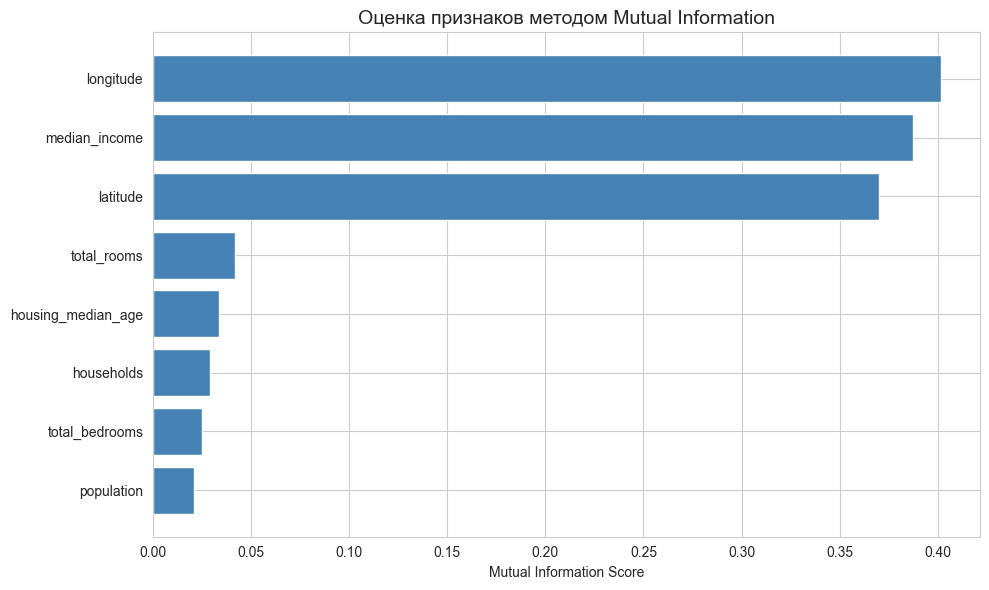

In [42]:
# Фильтрующий метод: Mutual Information
# Оцениваем взаимную информацию каждого признака с целевой переменной

mi_scores = mutual_info_regression(X_housing, y_housing, random_state=42)
mi_df = pd.DataFrame({
    'Feature': housing_features,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('Ранжирование признаков по Mutual Information:')
print(mi_df.round(4))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'], mi_df['MI_Score'], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Оценка признаков методом Mutual Information', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [43]:
# Отбор топ-5 признаков с помощью SelectKBest
selector_kbest = SelectKBest(mutual_info_regression, k=5)
X_kbest = selector_kbest.fit_transform(X_housing, y_housing)

selected_mask = selector_kbest.get_support()
selected_features = [housing_features[i] for i in range(len(housing_features)) if selected_mask[i]]

print('Отобрано признаков (SelectKBest, k=5):')
for f in selected_features:
    print(f'  - {f}')

# Сравнение качества модели с отобранными признаками
X_train, X_test, y_train, y_test = train_test_split(
    X_housing[selected_features], y_housing, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f'\nКачество модели с отобранными признаками:')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'R2: {r2_score(y_test, y_pred):.4f}')

Отобрано признаков (SelectKBest, k=5):
  - longitude
  - latitude
  - housing_median_age
  - total_rooms
  - median_income

Качество модели с отобранными признаками:
RMSE: 73793.10
R2: 0.5844


### 5.2. Метод-обёртка: Sequential Feature Selector (SFS)

Sequential Feature Selector (из библиотеки mlxtend) последовательно добавляет (forward) или удаляет (backward) признаки, оценивая качество модели на каждом шаге.

Применим Forward Selection на датасете Auto MPG для прогнозирования `mpg`.

In [44]:
# Подготовка данных Auto MPG
mpg_features = ['cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model-year']

X_mpg = mpg_clean[mpg_features]
y_mpg = mpg_clean['mpg']

print(f'Размер матрицы признаков: {X_mpg.shape}')

Размер матрицы признаков: (398, 6)


In [45]:
# Sequential Forward Selection (SFS)
# Используем LinearRegression как оценочную модель

sfs = SFS(
    LinearRegression(),
    k_features=3,
    forward=True,
    floating=False,
    scoring='r2',
    cv=5
)
sfs.fit(X_mpg, y_mpg)

print('Результаты Sequential Feature Selector:')
print(f'Лучшее подмножество признаков: {sfs.k_feature_names_}')
print(f'Лучший R2 score: {sfs.k_score_:.4f}')

# Визуализация результатов
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sfs_df = sfs_df.sort_values('avg_score', ascending=False)

print('\nВсе оцененные подмножества:')
for idx, row in sfs_df.iterrows():
    print(f'  Признаки: {row["feature_names"]}, R2: {row["avg_score"]:.4f}')

Результаты Sequential Feature Selector:
Лучшее подмножество признаков: ('cylinders', 'weight', 'model-year')
Лучший R2 score: 0.5914

Все оцененные подмножества:
  Признаки: ('weight', 'model-year'), R2: 0.5930
  Признаки: ('cylinders', 'weight', 'model-year'), R2: 0.5914
  Признаки: ('weight',), R2: 0.3119


In [46]:
# Сравнение: модель со всеми признаками vs с отобранными
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42
)

# Все признаки
lr_all = LinearRegression()
lr_all.fit(X_train_all, y_train)
y_pred_all = lr_all.predict(X_test_all)

# Отобранные признаки
selected_cols = list(sfs.k_feature_names_)
X_train_sel = X_train_all[selected_cols]
X_test_sel = X_test_all[selected_cols]

lr_sel = LinearRegression()
lr_sel.fit(X_train_sel, y_train)
y_pred_sel = lr_sel.predict(X_test_sel)

print('Сравнение моделей:')
print(f'  Все признаки ({len(mpg_features)}): RMSE={np.sqrt(mean_squared_error(y_test, y_pred_all)):.3f}, R2={r2_score(y_test, y_pred_all):.4f}')
print(f'  Отобранные ({len(selected_cols)}): RMSE={np.sqrt(mean_squared_error(y_test, y_pred_sel)):.3f}, R2={r2_score(y_test, y_pred_sel):.4f}')

Сравнение моделей:
  Все признаки (6): RMSE=3.072, R2=0.8244
  Отобранные (3): RMSE=3.081, R2=0.8235


### 5.3. Встроенный метод: Lasso (L1-регуляризация) и SelectFromModel

Lasso-регрессия использует L1-регуляризацию, которая обнуляет коэффициенты незначимых признаков, выполняя тем самым отбор признаков в процессе обучения.

Применим на датасете California Housing.

In [47]:
# Встроенный метод: Lasso (L1-регуляризация)

X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Масштабирование важно для Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso с разными alpha
alphas = [0.001, 0.01, 0.1, 1.0]

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    
    n_selected = np.sum(lasso.coef_ != 0)
    y_pred = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    print(f'alpha={alpha:.3f}: выбрано {n_selected}/{len(housing_features)} признаков, R2={r2:.4f}')
    for i, (feat, coef) in enumerate(zip(housing_features, lasso.coef_)):
        if coef != 0:
            print(f'    {feat:25s}: {coef:.2f}')

alpha=0.001: выбрано 8/8 признаков, R2=0.6139
    longitude                : -85503.21
    latitude                 : -90698.84
    housing_median_age       : 14905.91
    total_rooms              : -17805.40
    total_bedrooms           : 48712.32
    population               : -43766.48
    households               : 17654.50
    median_income            : 77194.70
alpha=0.010: выбрано 8/8 признаков, R2=0.6139
    longitude                : -85503.11
    latitude                 : -90698.75
    housing_median_age       : 14905.91
    total_rooms              : -17805.23
    total_bedrooms           : 48712.15
    population               : -43766.43
    households               : 17654.45
    median_income            : 77194.66
alpha=0.100: выбрано 8/8 признаков, R2=0.6139
    longitude                : -85502.17
    latitude                 : -90697.84
    housing_median_age       : 14905.96
    total_rooms              : -17803.54
    total_bedrooms           : 48710.41
    populat

In [48]:
# SelectFromModel с RandomForest
# Используем важность признаков из RandomForest для отбора

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Важность признаков
feature_importance = pd.DataFrame({
    'Feature': housing_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('Важность признаков (RandomForest):')
print(feature_importance.round(4))

# Отбор признаков с помощью SelectFromModel
selector = SelectFromModel(rf, threshold='median')
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_features_rf = [housing_features[i] for i in range(len(housing_features)) if selected_mask[i]]

print(f'\nОтобрано признаков (SelectFromModel + RF, threshold=median): {len(selected_features_rf)}')
print('Отобранные признаки:')
for f in selected_features_rf:
    print(f'  - {f}')

Важность признаков (RandomForest):
              Feature  Importance
7       median_income      0.5207
0           longitude      0.1564
1            latitude      0.1461
2  housing_median_age      0.0660
5          population      0.0379
4      total_bedrooms      0.0284
3         total_rooms      0.0246
6          households      0.0200

Отобрано признаков (SelectFromModel + RF, threshold=median): 4
Отобранные признаки:
  - longitude
  - latitude
  - housing_median_age
  - median_income


In [49]:
# Сравнение всех методов отбора признаков

print('Сводка результатов отбора признаков:')
print('=' * 60)

print('\n1. Фильтрующий метод (Mutual Information + SelectKBest):')
print(f'   Отобрано признаков: {len(selected_features)}')
for f in selected_features:
    print(f'     - {f}')

print(f'\n2. Метод-обёртка (SequentialFeatureSelector):')
print(f'   Отобрано признаков: {len(selected_cols)}')
for f in selected_cols:
    print(f'     - {f}')

print(f'\n3. Встроенный метод (SelectFromModel + RandomForest):')
print(f'   Отобрано признаков: {len(selected_features_rf)}')
for f in selected_features_rf:
    print(f'     - {f}')

print('\nВывод: различные методы отбора признаков могут давать разные результаты.')
print('Фильтрующие методы быстры, но не учитывают взаимодействия признаков.')
print('Методы-обёртки учитывают модель, но требуют больше вычислений.')
print('Встроенные методы сочетают преимущества обоих подходов.')

Сводка результатов отбора признаков:

1. Фильтрующий метод (Mutual Information + SelectKBest):
   Отобрано признаков: 5
     - longitude
     - latitude
     - housing_median_age
     - total_rooms
     - median_income

2. Метод-обёртка (SequentialFeatureSelector):
   Отобрано признаков: 3
     - cylinders
     - weight
     - model-year

3. Встроенный метод (SelectFromModel + RandomForest):
   Отобрано признаков: 4
     - longitude
     - latitude
     - housing_median_age
     - median_income

Вывод: различные методы отбора признаков могут давать разные результаты.
Фильтрующие методы быстры, но не учитывают взаимодействия признаков.
Методы-обёртки учитывают модель, но требуют больше вычислений.
Встроенные методы сочетают преимущества обоих подходов.
